# Sunrise Social Club: Exploratory Data Analysis

## Objective:
Analyze cafe sales data to understand product performance, customer behavior, and operational patterns across items, flavors, customization options, and time of day.

## Section 1: Loading the Data & Overview

In [435]:
#importing libraries
import numpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [436]:
#loading the data
df = pd.read_csv("../data/processed/sales_merged.csv")
df.head()

,Date,Time,Original_Item,Item,Base,Signature_Drink,Qty,Net_Sales,Size,Cold_Foam,Flavor,Avg_Temp,Weather_Condition,Event_Type,Location
0,2026-06-20,13:04:59,Lemonade,Lemonade,Lemonade,False,1.0,4.0,12oz,False,Strawberry,80,Sunny,Market,Manteo
1,2026-06-20,13:04:59,Matcha Latte,Matcha Latte,Whole Milk,False,1.0,7.0,12oz,False,Vanilla,80,Sunny,Market,Manteo
2,2026-06-20,12:45:36,Matcha Latte,Matcha Latte,Oat Milk,False,1.0,7.0,12oz,False,Strawberry,80,Sunny,Market,Manteo
3,2026-06-20,12:45:36,Matcha Latte,Matcha Latte,Oat Milk,False,1.0,8.0,12oz,True,Strawberry,80,Sunny,Market,Manteo
4,2026-06-20,12:44:22,Lemonade,Lemonade,Lemonade,False,1.0,5.0,16oz,False,Strawberry,80,Sunny,Market,Manteo


Each row represents a single line-item transaction (not a full customer order). Orders may contain multiple items across multiple rows.

In [437]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1103 entries, 0 to 1102
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               1103 non-null   object 
 1   Time               1103 non-null   object 
 2   Original_Item      1103 non-null   object 
 3   Item               1103 non-null   object 
 4   Base               732 non-null    object 
 5   Signature_Drink    1103 non-null   bool   
 6   Qty                1103 non-null   float64
 7   Net_Sales          1103 non-null   float64
 8   Size               844 non-null    object 
 9   Cold_Foam          1103 non-null   bool   
 10  Flavor             882 non-null    object 
 11  Avg_Temp           1103 non-null   int64  
 12  Weather_Condition  1103 non-null   object 
 13  Event_Type         1103 non-null   object 
 14  Location           1103 non-null   object 
dtypes: bool(2), float64(2), int64(1), object(10)
memory usage: 114.3+ KB


,Qty,Net_Sales,Avg_Temp
count,1103.000000,1103.000000,1103.000000
mean,1.128740,7.650426,80.572983
std,0.387789,4.335214,3.328897
min,1.000000,2.000000,75.000000
25%,1.000000,6.000000,79.000000
50%,1.000000,8.000000,80.000000
75%,1.000000,8.000000,83.000000
max,4.000000,75.000000,86.000000


### Exploring Missing Values:

In [438]:
# Percentage of missing values in each column
(df.isna().mean() * 100).sort_values(ascending=False)

Base                 33.635539
Size                 23.481414
Flavor               20.036265
Date                  0.000000
Time                  0.000000
Original_Item         0.000000
Item                  0.000000
Signature_Drink       0.000000
Qty                   0.000000
Net_Sales             0.000000
Cold_Foam             0.000000
Avg_Temp              0.000000
Weather_Condition     0.000000
Event_Type            0.000000
Location              0.000000
dtype: float64

### Data Quality Notes:

Several fields contain missing values due to limitations in the point-of-sale system, product characteristics, or operational inconsistencies.

- **Base** is missing for a subset of transactions. Some missing values occur because non-beverage merchandise items (e.g., stickers and mugs) do not require a milk base, while others could not be reliably determined from the available data. These values were retained as missing and later handled appropriately during beverage-specific analyses.
- **Size** is missing for some transactions. While size may be partially inferable from pricing, reconstructing it would require assumptions about add-ons and pricing rules, so missing values were retained.
- **Flavor** is missing for transactions where no flavor was added (e.g., plain Cold Brew, Matcha Latte, or Lemonade). Additionally, merchandise items do not have associated flavor selections. These missing values therefore represent valid non-selections rather than data entry errors.
- Core transaction fields (**Date, Time, Item, Quantity, and Net Sales**) are complete and serve as the primary basis for analysis.

In [439]:
df['Base']= df['Base'].fillna('Unknown')
df['Size']= df['Size'].fillna('Unknown')
df['Flavor']= df['Flavor'].fillna('No Syrup')

## Section 2: Business Performance Overview

### 2.1 Sales Overview

In [440]:
print(f'Total Net Sales: ${df["Net_Sales"].sum():,.2f}')
print(f'Total Quantity Sold: {df["Qty"].sum():,}')

Total Net Sales: $8,438.42
Total Quantity Sold: 1,245.0


In [441]:
df["Net_Sales"].describe()

count    1103.000000
mean        7.650426
std         4.335214
min         2.000000
25%         6.000000
50%         8.000000
75%         8.000000
max        75.000000
Name: Net_Sales, dtype: float64

### 2.2 Customer Order Value

In [442]:
order_level = (
    df.groupby(["Date", "Time"])["Net_Sales"]
      .sum()
)

# Summary statistics
print(order_level.describe())

print(f"Average Order Value: ${order_level.mean():.2f}")
print(f"Median Order Value: ${order_level.median():.2f}")

count    745.000000
mean      11.326738
std        6.851287
min        2.000000
25%        8.000000
50%        9.000000
75%       14.000000
max       93.000000
Name: Net_Sales, dtype: float64
Average Order Value: $11.33
Median Order Value: $9.00


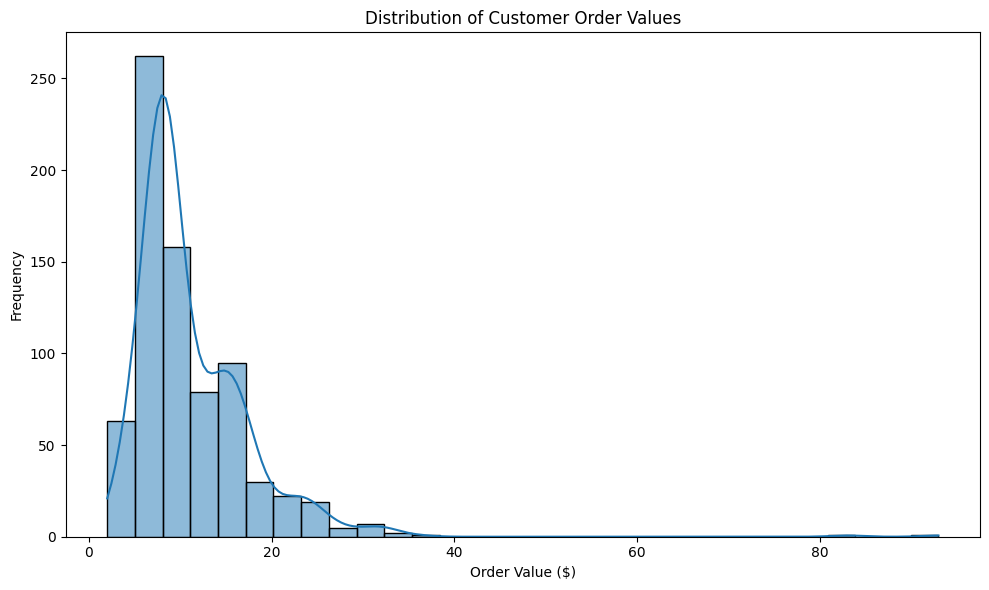

In [443]:
plt.figure(figsize=(10, 6))
sns.histplot(order_level, bins=30, kde=True)
plt.title("Distribution of Customer Order Values")
plt.xlabel("Order Value ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Most customer orders fall between $8 and $14, with an average order value of $11.43. A small number of larger purchases create a right-skewed distribution.

## Section 3: Product Performance
This section explores which products drive demand and revenue.

### 3.1 Revenue by Item

In [444]:
items_by_revenue = df.groupby('Item')['Net_Sales'].sum().sort_values(ascending=False)
items_by_revenue

Item
Matcha Latte    4605.42
Cold Brew       2424.00
Lemonade        1077.00
Sticker          182.00
Mug              150.00
Name: Net_Sales, dtype: float64

### 3.2 Quantity by Item

In [445]:
items_by_quantity = df.groupby('Item')['Qty'].sum().sort_values(ascending=False)
items_by_quantity

Item
Matcha Latte    569.0
Cold Brew       336.0
Lemonade        247.0
Sticker          91.0
Mug               2.0
Name: Qty, dtype: float64

### 3.3 Revenue vs. Quantity

In [446]:
item_stats = df.groupby("Item").agg(
    Net_Sales=("Net_Sales", "sum"),
    Qty=("Qty", "sum")).abs().sort_values("Net_Sales", ascending=False)

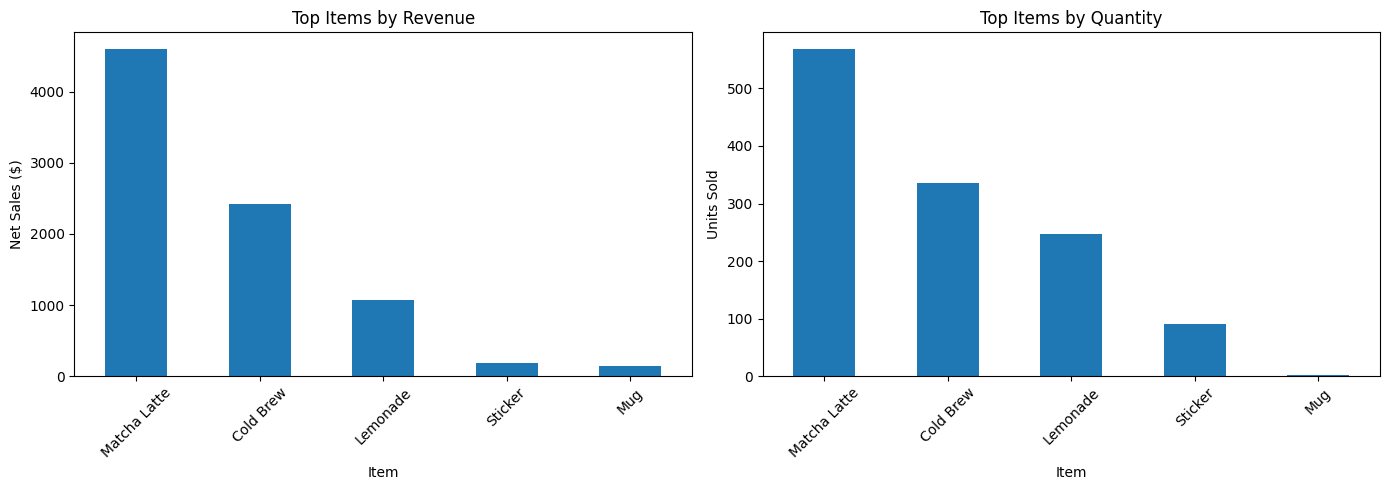

In [447]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue
item_stats["Net_Sales"].plot(kind="bar", ax=axes[0])
axes[0].set_title("Top Items by Revenue")
axes[0].set_ylabel("Net Sales ($)")
axes[0].tick_params(axis='x', rotation=45)

# Quantity
item_stats["Qty"].plot(kind="bar", ax=axes[1])
axes[1].set_title("Top Items by Quantity")
axes[1].set_ylabel("Units Sold")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

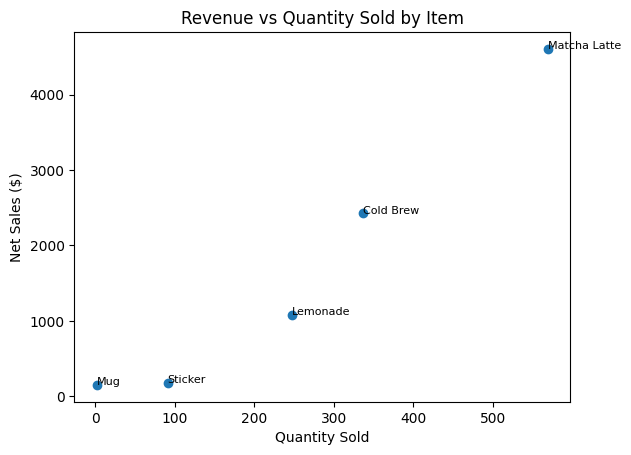

In [448]:
plt.scatter(item_stats["Qty"], item_stats["Net_Sales"])
plt.xlabel("Quantity Sold")
plt.ylabel("Net Sales ($)")
plt.title("Revenue vs Quantity Sold by Item")

for i in item_stats.index:
    plt.text(item_stats.loc[i, "Qty"], item_stats.loc[i, "Net_Sales"], i, fontsize=8)

plt.show()

- Matcha Latte dominates both revenue and quantity, indicating it is the core driver of both demand and sales.
- Cold Brew shows high volume but lower revenue efficiency compared to Matcha Latte, suggesting lower price per unit.
- Lemonade performs relatively well in quantity but contributes less revenue, reinforcing its role as a high-volume, lower-margin product.
- Merchandise items (Sticker, Mug) generate revenue despite low volume, highlighting their role as high-margin add-ons rather than core demand drivers.

## Section 4: Customer Preferences

In [449]:
# Filter dataset to only include drink items
drink_items = ["Matcha Latte", "Cold Brew", "Lemonade"]

drink_df = df[df["Item"].isin(drink_items)]

### 4.1 Flavor Popularity

In [450]:
flavor_stats = drink_df.groupby("Flavor").agg(
    Net_Sales=("Net_Sales", "sum"),
    Qty=("Qty", "sum")).abs().sort_values("Net_Sales", ascending=False)
flavor_stats

,Net_Sales,Qty
Flavor,,
Strawberry,2773.58,390.0
Blueberry,1183.00,156.0
Salted Maple,1135.66,147.0
No Syrup,953.18,176.0
Vanilla,674.00,90.0
Cinn Roll,609.00,78.0
Banana,367.00,46.0
Cake Batter,224.00,28.0
"Strawberry, Blueberry",187.00,41.0


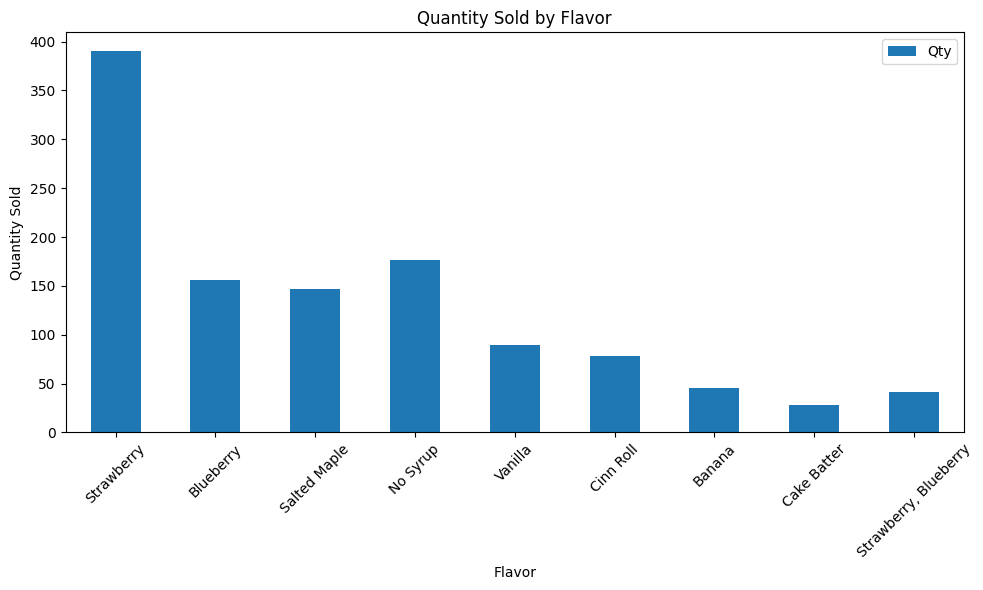

In [468]:
flavor_stats.plot(kind="bar", y="Qty", figsize=(10, 6))
plt.title("Quantity Sold by Flavor")
plt.ylabel("Quantity Sold")
plt.xlabel("Flavor")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Strawberry was the most frequently selected flavor, suggesting strong customer preference for fruit-based drinks.

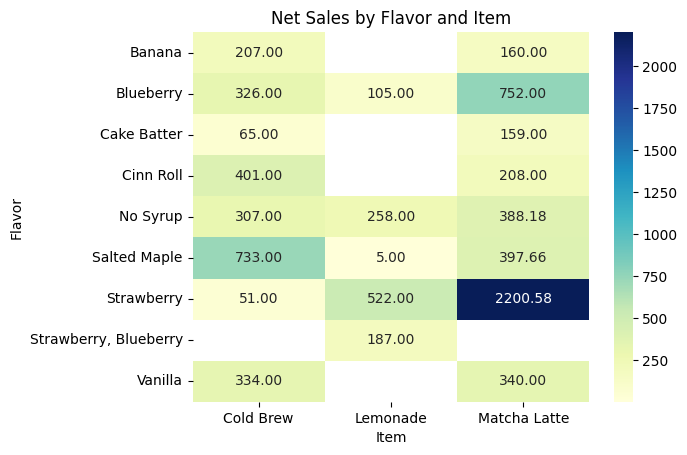

In [452]:
pivot = drink_df.pivot_table(
    index="Flavor",
    columns="Item",
    values="Net_Sales",
    aggfunc="sum"
)
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Net Sales by Flavor and Item")
plt.xlabel("Item")
plt.ylabel("Flavor")
plt.show()

The heatmap reveals that strawberry was the most popular flavor for both matcha lattes and lemonades, while salted maple was the most popular flavor for cold brews.

### 4.2 Milk Preferences

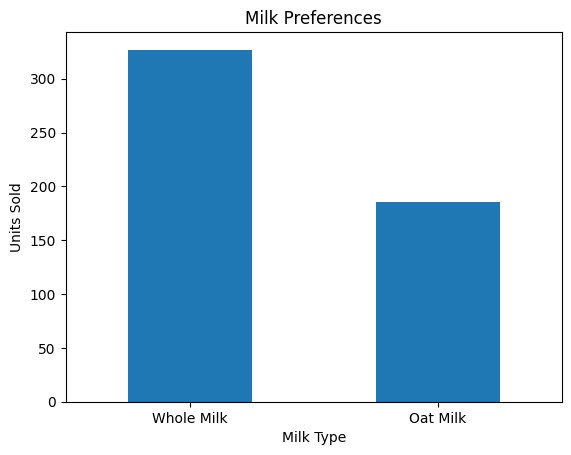

In [453]:
milk_df = drink_df[drink_df["Base"].isin(["Whole Milk", "Oat Milk"])]

milk_pref = milk_df.groupby("Base")["Qty"].sum().sort_values(ascending=False)

milk_pref.plot(kind="bar")
plt.title("Milk Preferences")
plt.xlabel("Milk Type")
plt.ylabel("Units Sold")
plt.xticks(rotation=0)
plt.show()

Whole milk was selected more frequently than oat milk, suggesting that customers generally preferred traditional dairy options.

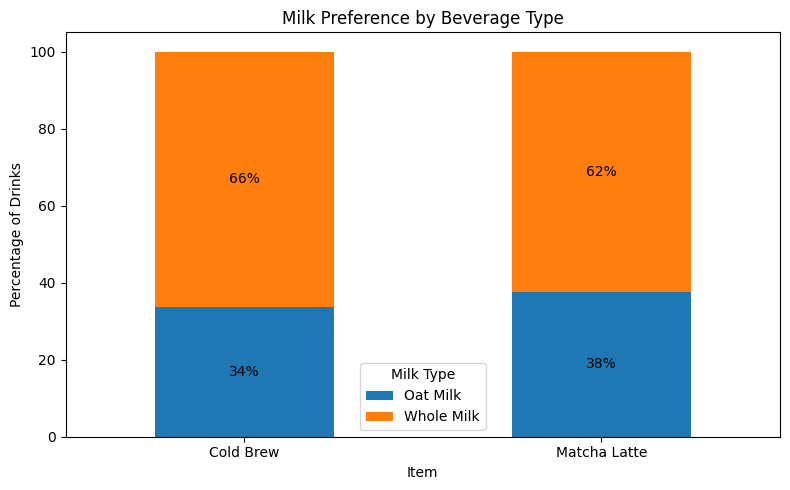

In [454]:
# Milk Preference by Beverage Type
milk_item_pct = (
    drink_df[drink_df["Item"].isin(["Matcha Latte", "Cold Brew"])]
      .query('Base in ["Whole Milk", "Oat Milk"]')
      .groupby(["Item", "Base"])["Qty"]
      .sum()
      .unstack(fill_value=0)
)

# Convert to percentages
milk_item_pct = milk_item_pct.div(
    milk_item_pct.sum(axis=1), axis=0
) * 100

ax = milk_item_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Milk Preference by Beverage Type")
plt.ylabel("Percentage of Drinks")
plt.xlabel("Item")
plt.xticks(rotation=0)
plt.legend(title="Milk Type")

for container in ax.containers:
    labels = [f"{v:.0f}%" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center")

plt.tight_layout()
plt.show()

### 4.3 Cold Foam Preferences

In [455]:
drink_df.groupby("Cold_Foam").agg(
    Net_Sales=("Net_Sales", "sum"),
    Qty=("Qty", "sum")).abs().sort_values("Net_Sales", ascending=False) 

,Net_Sales,Qty
Cold_Foam,,
True,4654.50,571.0
False,3451.92,581.0


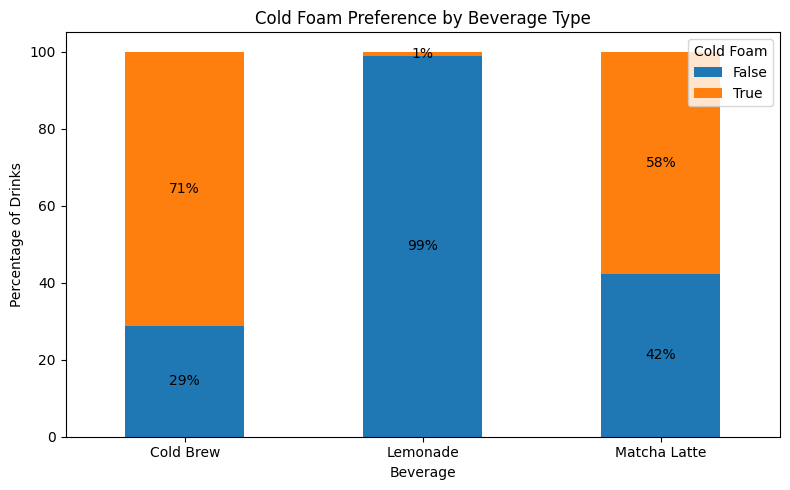

In [456]:
foam_by_item = (
    drink_df.groupby(["Item", "Cold_Foam"])["Qty"]
    .sum()
    .unstack(fill_value=0)
)

foam_by_item_pct = foam_by_item.div(foam_by_item.sum(axis=1), axis=0) * 100

ax = foam_by_item_pct.plot(kind="bar", stacked=True, figsize=(8,5))

plt.title("Cold Foam Preference by Beverage Type")
plt.ylabel("Percentage of Drinks")
plt.xlabel("Beverage")
plt.xticks(rotation=0)
plt.legend(title="Cold Foam")

for container in ax.containers:
    labels = [f"{v:.0f}%" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center")

plt.tight_layout()
plt.show()

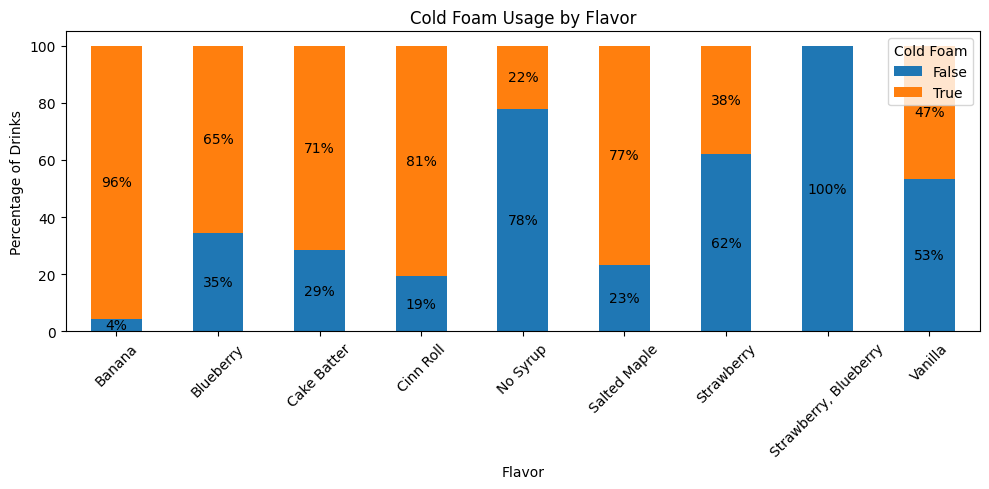

In [457]:
foam_by_flavor = (
    drink_df.groupby(["Flavor", "Cold_Foam"])["Qty"]
    .sum()
    .unstack(fill_value=0)
)

foam_by_flavor_pct = foam_by_flavor.div(foam_by_flavor.sum(axis=1), axis=0) * 100

ax = foam_by_flavor_pct.plot(kind="bar", stacked=True, figsize=(10,5))

plt.title("Cold Foam Usage by Flavor")
plt.ylabel("Percentage of Drinks")
plt.xlabel("Flavor")
plt.xticks(rotation=45)
plt.legend(title="Cold Foam")

for container in ax.containers:
    labels = [f"{v:.0f}%" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center")

plt.tight_layout()
plt.show()

## Section 5: Event and Operational Analysis

### 5.1 Revenue by Event Type

In [458]:
df.groupby("Event_Type")["Net_Sales"].sum()

Event_Type
Delivery      57.00
Market      7010.42
Popup       1371.00
Name: Net_Sales, dtype: float64

In [459]:
# Average daily sales by event type
daily_sales = (
    df.groupby(["Date", "Event_Type"])["Net_Sales"]
      .sum()
      .reset_index()
)

avg_sales = (
    daily_sales.groupby("Event_Type")["Net_Sales"]
    .mean()
    .sort_values(ascending=False)
)

avg_sales

Event_Type
Market      1168.403333
Popup        457.000000
Delivery      57.000000
Name: Net_Sales, dtype: float64

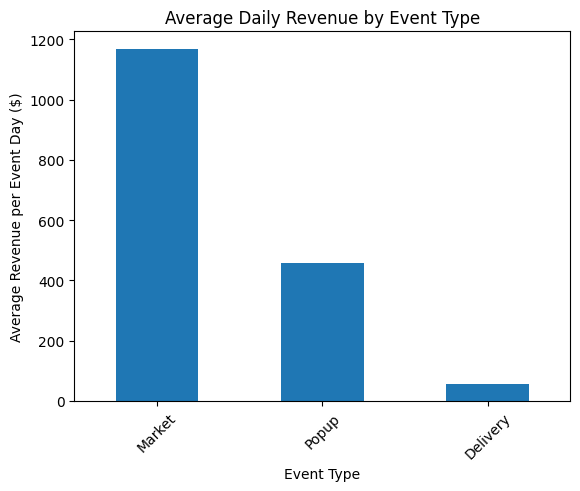

In [460]:
avg_sales.plot(kind="bar")
plt.title("Average Daily Revenue by Event Type")
plt.ylabel("Average Revenue per Event Day ($)")
plt.xlabel("Event Type")
plt.xticks(rotation=45)
plt.show()

### 5.2 Revenue by Market Location

Note: Market locations differ in external setup costs (Manteo and First Flight: $25 entry fee; Soundside: $160 entry fee), which are not included in the dataset. Therefore, revenue comparisons reflect observed sales performance only and do not account for differences in operating costs or market scale.


In [461]:
# Filter dataset to only include market locations
market_locations = ["Manteo", "First Flight", "Soundside"]

market_df = df[df["Location"].isin(market_locations)]

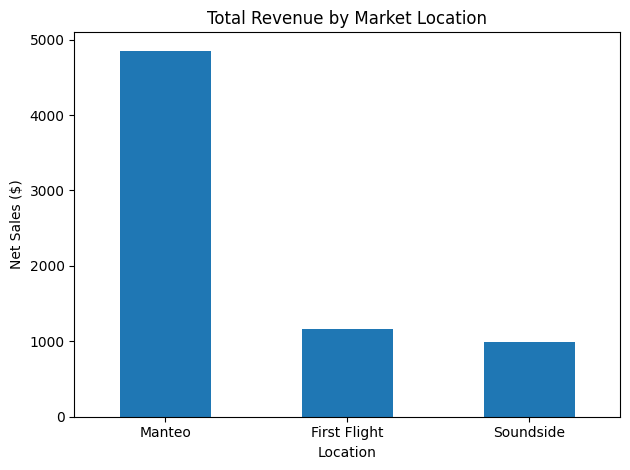

In [462]:
# Total revenue by market location
location_revenue = (
    market_df.groupby("Location")["Net_Sales"]
    .sum()
    .sort_values(ascending=False)
)

location_revenue.plot(kind="bar")

plt.title("Total Revenue by Market Location")
plt.xlabel("Location")
plt.ylabel("Net Sales ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

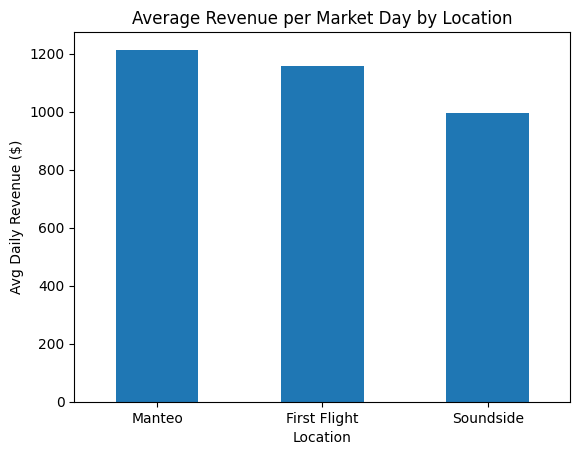

In [463]:
# Average daily revenue by market location
daily_market = (
    market_df.groupby(["Date", "Location"])["Net_Sales"]
    .sum()
    .reset_index()
)

avg_market = (
    daily_market.groupby("Location")["Net_Sales"]
    .mean()
    .sort_values(ascending=False)
)

avg_market.plot(kind="bar")
plt.title("Average Revenue per Market Day by Location")
plt.ylabel("Avg Daily Revenue ($)")
plt.xlabel("Location")
plt.xticks(rotation=0)
plt.show()

### 5.3 Time-Based Patterns

In [464]:
df["Hour"] = pd.to_datetime(df["Time"]).dt.hour

/var/folders/w2/4nk24xz14yg09dbpyrxdn4c80000gn/T/ipykernel_73939/816105062.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Hour"] = pd.to_datetime(df["Time"]).dt.hour


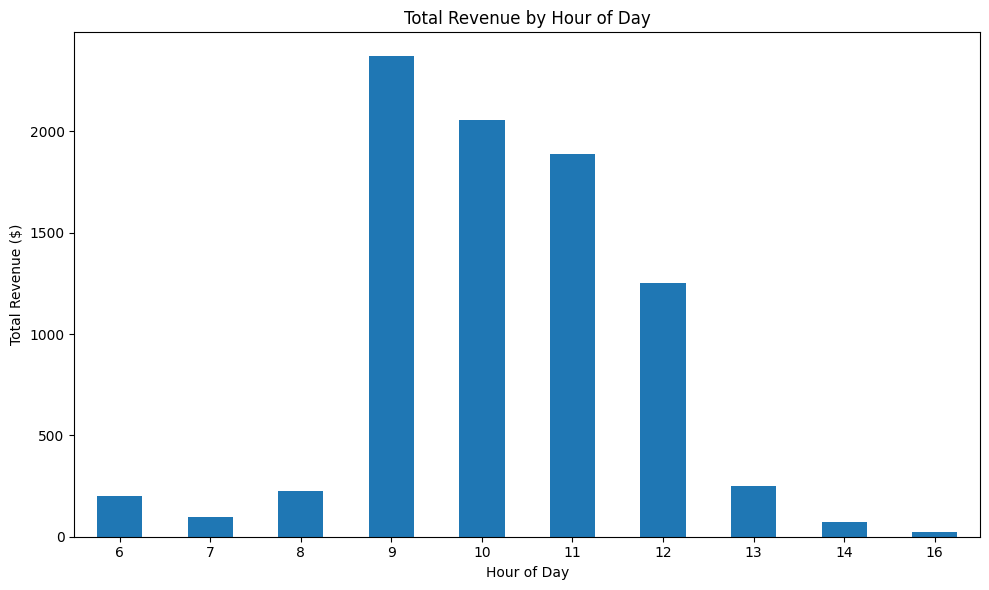

In [465]:
df.groupby("Hour")["Net_Sales"].sum().plot(kind="bar", figsize=(10, 6))
plt.title("Total Revenue by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The peak sales hours are from 9am-1pm, which the time frame in which all of the markets occur. In that, the first hour of the markets, 9-10am, generates the most revenue.

### 5.4 Weather Based Patterns

In [466]:
drink_df.groupby('Item')['Avg_Temp'].mean().sort_values(ascending=False)

Item
Lemonade        81.129808
Matcha Latte    80.488372
Cold Brew       80.465347
Name: Avg_Temp, dtype: float64

Lemonade purchases occurred on slightly warmer days on average than Cold Brew and Matcha Latte purchases, suggesting that customer demand for lemonade may be more sensitive to temperature.

## Section 6: Key Insights and Recommendations

Key Findings

Matcha Latte is the primary revenue driver.

Customers exhibit strong preference for flavored beverages.

Markets outperform other event formats on average.

Sales are concentrated during morning hours.

Business Recommendations

Prioritize inventory for Matcha Lattes and strawberry syrup.

Expand high-performing market events.

Schedule staffing around peak morning demand.